# Notebook for LSTM 
Most recent update (02.04.2024): construct a univariate LSTM to implement the lagged approach.

In [1]:
#importing functions and  packages 
import numpy as np
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from helpers import fix_datetime_format, create_sliding_windows
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, InputLayer, Input, Flatten,  RepeatVector, TimeDistributed
from tensorflow.keras import Input



ModuleNotFoundError: No module named 'tensorflow'

In [2]:
random_state = 42

## Data Import & Preprocessing

In [3]:
# Data import
data = pd.read_csv("data/final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})

#remove 2025 data
data = data[data["full_datetime"] < "2025-01-01-01"]
data.tail()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor,correct_days
70123,20241231,20,211.999178,146.000000,151.333333,10141.5,86.571429,2024-12-31-20,3718000,3718000,0.894180,0,0,2024-12-31-20
70124,20241231,21,210.666633,146.000000,148.000000,10133.5,86.857143,2024-12-31-21,3744500,3744500,0.900553,0,0,2024-12-31-21
70125,20241231,22,210.000000,146.000000,149.333333,10124.0,88.285714,2024-12-31-22,3686750,3686750,0.886664,0,0,2024-12-31-22
70126,20241231,23,213.336340,150.000000,149.333333,10118.5,88.857143,2024-12-31-23,3719250,3719250,0.894481,0,0,2024-12-31-23
70127,20241231,24,214.005693,152.666667,153.333333,10109.5,87.428571,2024-12-31-24,3453249,3453249,0.830507,0,0,2024-12-31-24


In [4]:
# fix correct_days variable and turn into index
# Apply the fix
data["correct_days"] = data["correct_days"].apply(fix_datetime_format)

#set index
data.set_index('correct_days', inplace=True)
data.tail()

,year_mon_day,hour,wind_dir_avg_10,wind_speed_h_avg,wind_speed_avg_10,air_pressure,humidity,full_datetime,capacity,volume,percentage,emission,emissionfactor
correct_days,,,,,,,,,,,,,
2024-12-31 20:00:00,20241231,20,211.999178,146.000000,151.333333,10141.5,86.571429,2024-12-31-20,3718000,3718000,0.894180,0,0
2024-12-31 21:00:00,20241231,21,210.666633,146.000000,148.000000,10133.5,86.857143,2024-12-31-21,3744500,3744500,0.900553,0,0
2024-12-31 22:00:00,20241231,22,210.000000,146.000000,149.333333,10124.0,88.285714,2024-12-31-22,3686750,3686750,0.886664,0,0
2024-12-31 23:00:00,20241231,23,213.336340,150.000000,149.333333,10118.5,88.857143,2024-12-31-23,3719250,3719250,0.894481,0,0
2025-01-01 00:00:00,20241231,24,214.005693,152.666667,153.333333,10109.5,87.428571,2024-12-31-24,3453249,3453249,0.830507,0,0


We first want to analyze the data using a lagged approach. Hence, all variables apart from volume need to be dropped.

In [5]:
X = pd.DataFrame(data["volume"])#we need the shape to be (70128, 1), not (70128, )
X.shape
X.head()

#check type of target variable 
type(X.volume[0])


#Separate the training from the test data before scaling so only the train data is scaled.
train_data = X["2017-01-01 01:00:00":"2024-12-24 23:00:00"]
test_data = X["2024-12-25 00:00:00":"2024-12-31 23:00:00"]

# convert to float as is recommended 
train_data_2 = train_data.values #turn into ndarray
train_data_2 = train_data_2.astype("float32")
train_data = pd.DataFrame(data=train_data_2, index = train_data.index.values, columns=["volume"])


test_data_2 = test_data.values
test_data_2 = test_data_2.astype("float32")
test_data = pd.DataFrame(data=test_data_2, index = test_data.index.values, columns=["volume"])

train_data.tail()
test_data.head()

/var/folders/xk/v_s45nd9057cbzm0wb_2259m0000gn/T/ipykernel_92161/1443158175.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  type(X.volume[0])


,volume
2024-12-25 00:00:00,952750.0
2024-12-25 01:00:00,858500.0
2024-12-25 02:00:00,753251.0
2024-12-25 03:00:00,503250.0
2024-12-25 04:00:00,434000.0


In [6]:
test_data.head()

,volume
2024-12-25 00:00:00,952750.0
2024-12-25 01:00:00,858500.0
2024-12-25 02:00:00,753251.0
2024-12-25 03:00:00,503250.0
2024-12-25 04:00:00,434000.0


Text(0.5, 1.0, 'Training Data')

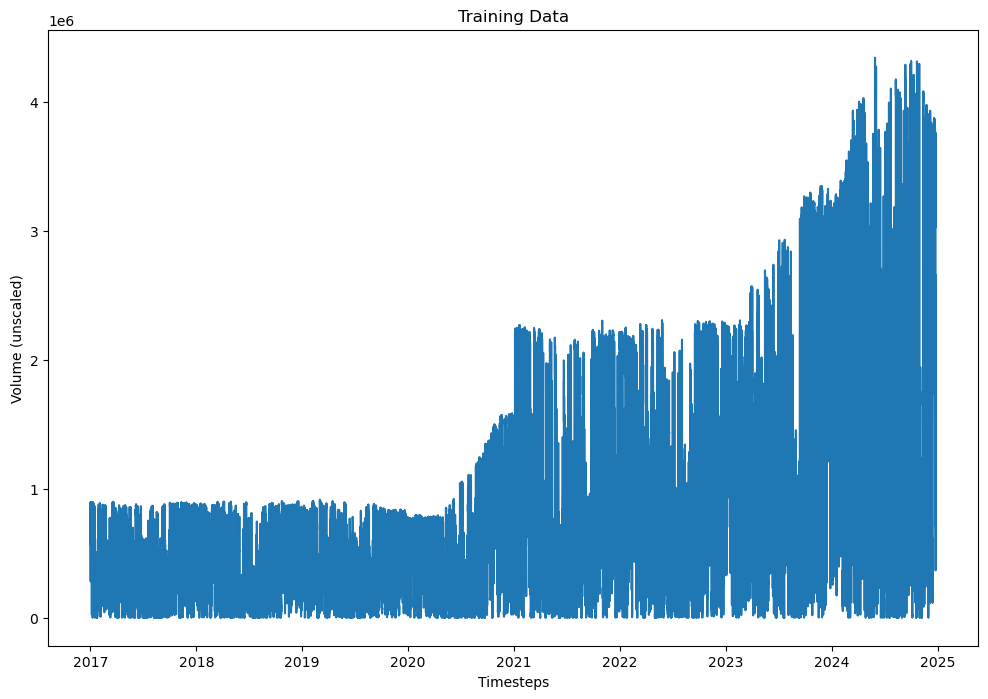

In [7]:
# quick plot
plt.figure(figsize=(12,8))
plt.plot(train_data)
plt.xlabel("Timesteps")
plt.ylabel("Volume (unscaled)")
plt.title("Training Data")

Text(0.5, 1.0, 'Test Data')

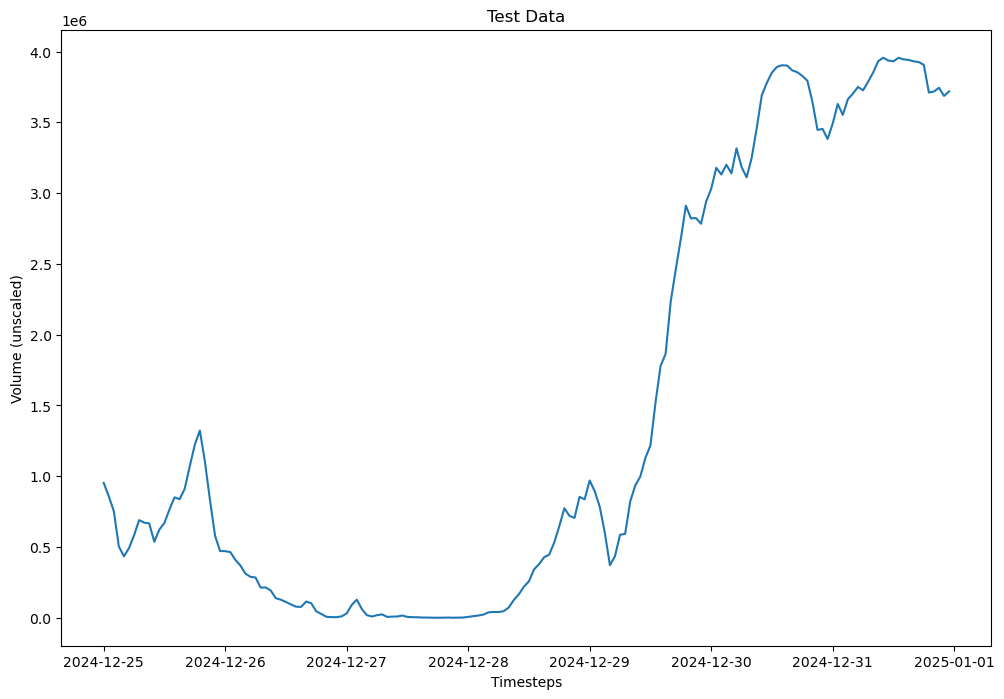

In [8]:
# quick plot
plt.figure(figsize=(12,8))
plt.plot(test_data)
plt.xlabel("Timesteps")
plt.ylabel("Volume (unscaled)")
plt.title("Test Data")

Normalize the data, because LSTM is sensitive to the scale of the input data.

In [43]:
object = StandardScaler()

#standardization
train_data = object.fit_transform(train_data)
train_data = object.transform(train_data)
test_data = object.transform(test_data)

print(train_data[:5])


[[-0.98164215]
 [-0.98164214]
 [-0.98164215]
 [-0.98164213]
 [-0.98164212]]


/opt/anaconda3/envs/ml_proj/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Create 3D-dataset

In [ ]:
X_train, y_train = create_sliding_windows(train_data, x_len=400, y_len=1)
X_test, y_test = create_sliding_windows(test_data, x_len=20, y_len=2) # 

## Model Creation 

In [55]:
# extract parameters for model definition
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]
n_outputs = y_train.shape[1]
n_batch = X_train.shape[0]

# create and fit LSTM 
model = Sequential()
model.add(LSTM(units=32, input_shape=X_train.shape[1:]))# apparently this is the "hidden neurons" (hyperparameter). No idea if this is correct)
model.add(Dense(1))
model.compile(loss="mean_squared_error", optimizer="adam")
model.fit(X_train, y_train, epochs=10, batch_size= 1, # how many samples the models sees before updating the weights 
          verbose=2)

Epoch 1/10


/opt/anaconda3/envs/ml_proj/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


174/174 - 11s - 62ms/step - loss: 0.0379
Epoch 2/10
174/174 - 9s - 53ms/step - loss: 2.1129e-10
Epoch 3/10
174/174 - 9s - 53ms/step - loss: 6.4484e-13
Epoch 4/10
174/174 - 9s - 53ms/step - loss: 7.9854e-13
Epoch 5/10
174/174 - 9s - 55ms/step - loss: 7.3854e-13
Epoch 6/10
174/174 - 9s - 53ms/step - loss: 1.0027e-12
Epoch 7/10
174/174 - 9s - 53ms/step - loss: 8.8367e-13
Epoch 8/10
174/174 - 9s - 54ms/step - loss: 1.1190e-12
Epoch 9/10
174/174 - 9s - 53ms/step - loss: 1.3242e-12
Epoch 10/10
174/174 - 9s - 54ms/step - loss: 9.7189e-13


## Predictions & Evaluation

In [57]:
# make predictions
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

#calculate MSE
train_score = np.sqrt(mean_squared_error(y_train[:, 0], train_preds[:, 0]))
print(train_score)
test_score = np.sqrt(mean_squared_error(y_test[:, 0], test_preds[:, 0]))
print(test_score)



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
7.984839189272829e-07
1.43085954397364


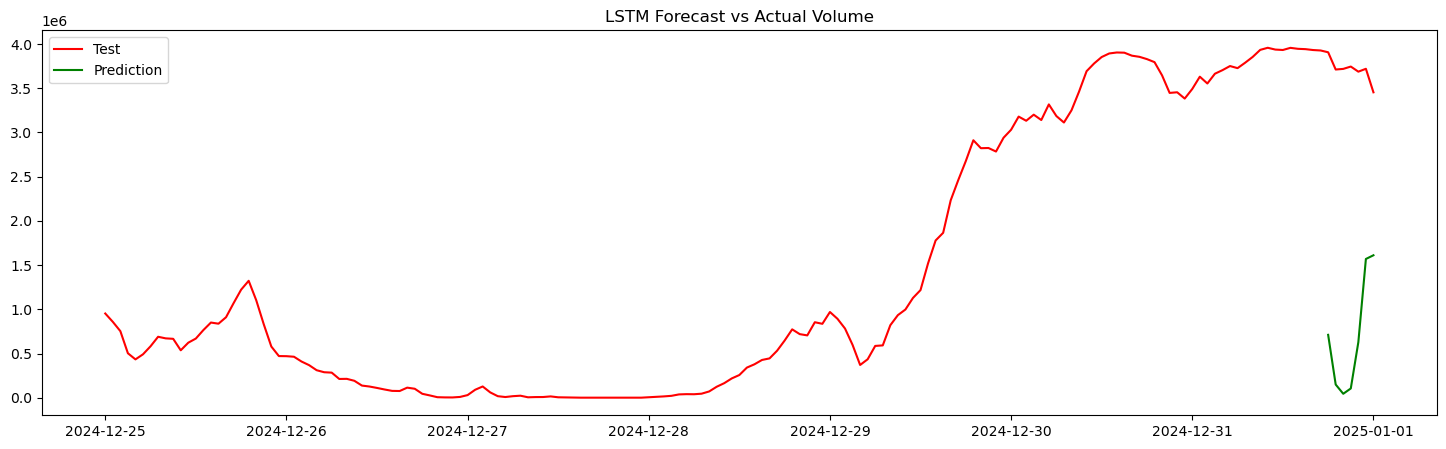

In [58]:
# get data with time indexes agai
train_data = X["2017-01-01 01:00:00":"2024-12-24 23:00:00"]
test_data = X["2024-12-25 00:00:00":]


test_preds = object.inverse_transform(test_preds)
test_preds = pd.DataFrame(data = test_preds, index=test_data.index.values[-7:], columns=["volume"])


# Plot predictions
plt.figure(figsize=(18,5))
plt.plot(test_data, label="Test", color="red")
plt.plot(test_preds, label="Prediction", color="green")
plt.legend()
plt.title("LSTM Forecast vs Actual Volume")
plt.show()



array([[ 591466.25],
       [ 133176.94],
       [  33958.5 ],
       [  75908.81],
       [ 539308.4 ],
       [1113052.5 ],
       [1099583.  ]], dtype=float32)

## LSTM with `torch`

In [2]:
#importing functions and  packages 
import numpy as np
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, classification_report, mean_absolute_error
from sklearn.compose import ColumnTransformer
from helpers import fix_datetime_format, create_sliding_windows
import torch 
import torch.nn as nn


### Import & Pre-Processing

In [168]:
# Data import
data = pd.read_csv("data/final_offshore_data_2017_2025.csv", dtype = {'year_mon_day':'int32'})

#remove 2025 data
data = data[data["full_datetime"] < "2025-01-01-01"]
# fix correct_days variable and turn into index
# Apply the fix
data["correct_days"] = data["correct_days"].apply(fix_datetime_format)

#set index
data.set_index('correct_days', inplace=True)



### Train-Test-Split

In [169]:
X = pd.DataFrame(data["volume"])#we need the shape to be (70128, 1), not (70128, )
X.shape
X.head()

#check type of target variable 
type(X.volume[0])


#Separate the training from the test data before scaling so only the train data is scaled.
#train_data = X["2017-01-01 01:00:00":"2024-12-24 23:00:00"]
#test_data = X["2024-12-25 00:00:00":"2024-12-31 23:00:00"]

train_data = X["2017-01-01 01:00:00":"2021-12-24 23:00:00"]
test_data = X["2021-12-25 00:00:00":"2024-12-31 23:00:00"]

# convert to float as is recommended 
train_data_2 = train_data.values #turn into ndarray
train_data_2 = train_data_2.astype("float32")
train_data = pd.DataFrame(data=train_data_2, index = train_data.index.values, columns=["volume"])


test_data_2 = test_data.values
test_data_2 = test_data_2.astype("float32")
test_data = pd.DataFrame(data=test_data_2, index = test_data.index.values, columns=["volume"])

train_data.tail()
test_data.head()

/var/folders/xk/v_s45nd9057cbzm0wb_2259m0000gn/T/ipykernel_48519/738453380.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  type(X.volume[0])


,volume
2021-12-25 00:00:00,1269500.0
2021-12-25 01:00:00,1362499.0
2021-12-25 02:00:00,1462250.0
2021-12-25 03:00:00,1636500.0
2021-12-25 04:00:00,1672000.0


### Scale Data

In [170]:
object = StandardScaler()

#standardization
object.fit_transform(train_data)
train_data = object.transform(train_data)
test_data = object.transform(test_data)

print(train_data[:5])

[[0.719182  ]
 [0.74082124]
 [0.7170684 ]
 [0.7534927 ]
 [0.76088524]]


### Create 3D-Data

In [171]:
X_train, y_train = create_sliding_windows(train_data, x_len=400, y_len=48)
X_test, y_test = create_sliding_windows(test_data, x_len=200, y_len=48) #

print(X_train)
print(X_test)

[[[ 0.719182  ]
  [ 0.74082124]
  [ 0.7170684 ]
  ...
  [-0.9246684 ]
  [-0.99593335]
  [-0.98326194]]

 [[-1.077224  ]
  [-1.0930628 ]
  [-1.0877839 ]
  ...
  [-0.90143913]
  [-0.5229428 ]
  [-0.6807837 ]]

 [[ 0.5671479 ]
  [ 0.5159427 ]
  [ 0.43253624]
  ...
  [-0.47965798]
  [ 0.06565342]
  [ 0.09257787]]

 ...

 [[ 2.7578893 ]
  [ 2.8993614 ]
  [ 3.0376682 ]
  ...
  [ 3.2968597 ]
  [ 3.282081  ]
  [ 3.3866029 ]]

 [[ 1.3531746 ]
  [ 1.3420889 ]
  [ 1.0834212 ]
  ...
  [ 1.9254041 ]
  [ 2.01198   ]
  [ 1.7490913 ]]

 [[ 2.4638531 ]
  [ 2.4448512 ]
  [ 2.4501278 ]
  ...
  [ 0.3908309 ]
  [ 0.4489029 ]
  [ 0.7302656 ]]]
[[[ 1.555356  ]
  [ 1.7517285 ]
  [ 1.9623584 ]
  ...
  [ 3.177031  ]
  [ 2.9748495 ]
  [ 3.3295908 ]]

 [[ 0.3718269 ]
  [ 0.83109236]
  [-0.05364948]
  ...
  [-0.77685946]
  [-0.7135128 ]
  [-0.61374176]]

 [[-1.0698357 ]
  [-1.0766983 ]
  [-1.0872561 ]
  ...
  [-0.906718  ]
  [-0.83492726]
  [-0.8502339 ]]

 ...

 [[ 6.023408  ]
  [ 6.6584587 ]
  [ 6.9778333 ]
  ..

### Model Creation

In [179]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size

    
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input, hidden):
        output, hidden = self.lstm(input, hidden)
        return output, hidden 

class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(Decoder, self).__init__()
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.hidden_size = hidden_size

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.rand(encoder_hidden.shape[1], 1, 32) # -0.98 is the mean of train_data
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(1):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i, :].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = nn.functional.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # We return `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = nn.functional.relu(input)
        context = torch.rand(1, input.shape[0], self.hidden_size)
        output, hidden = self.lstm(output, (hidden, context))
        output = self.out(output)
        return output, hidden

In [180]:
# initialize model 
encoder = Encoder(input_size=1, hidden_size=32, dropout_p=0.1)
encoder_optimizer = torch.optim.AdamW(encoder.parameters())


hidden = torch.rand(1, 97, 32)
context = torch.rand(1, 97, 32)

#turn train data from ndarray into tensor
#X_train = torch.from_numpy(X_train)

output, (hidden, context) = encoder(X_train, (hidden, context)) # output is embedding with three batches, 400 timesteps and 32 neurons



In [182]:
decoder = Decoder(hidden_size=32, 
 output_size=48) #predict 24h 
decoder_optimizer = torch.optim.AdamW(decoder.parameters())

loss_fn = nn.MSELoss()

#y_train = torch.from_numpy(y_train)
decoder_outputs, _, _, = decoder(output, hidden, y_train) #test dimensionality of embeddings, encoder and decoder outputs 



In [188]:
epochs = 1000

for i in range(epochs):
    
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    hidden = torch.rand(1, 97, 32)
    context = torch.rand(1, 97, 32)

    output, (hidden, context) = encoder(X_train, (hidden, context))
    decoder_outputs, _, _, = decoder(output, hidden, y_train)

    loss = loss_fn(
        decoder_outputs, y_train.reshape(97, 48))
    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()
    print(loss)







/opt/anaconda3/envs/ml_proj_torch/lib/python3.13/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([97, 48])) that is different to the input size (torch.Size([97, 1, 48])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(16.3934, grad_fn=<MseLossBackward0>)
tensor(16.3934, grad_fn=<MseLossBackward0>)
tensor(16.3934, grad_fn=<MseLossBackward0>)
tensor(16.3934, grad_fn=<MseLossBackward0>)
tensor(16.3934, grad_fn=<MseLossBackward0>)
tensor(16.3934, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3934, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3934, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLossBackward0>)
tensor(16.3933, grad_fn=<MseLoss

KeyboardInterrupt: 

In [189]:
# evaluation
#X_test = torch.from_numpy(X_test)
#y_test = torch.from_numpy(y_test)

with torch.no_grad():
        hidden = torch.rand(1, 106, 32)
        context = torch.rand(1, 106, 32)

        output, (hidden, context) = encoder(X_test, (hidden, context))
        #special = torch.rand(1, 163, 32)
        #target = torch.cat((hidden, special), dim=1)
        decoder_outputs, _, _, = decoder(output, hidden)
        print(y_test.shape, decoder_outputs.shape)
        result = mean_squared_error(y_test.reshape(-1, 1), decoder_outputs.reshape(-1, 1))

true = y_test
preds = decoder_outputs[0].reshape(-1, 1)


torch.Size([106, 48, 1]) torch.Size([106, 1, 48])
